## Importing libraries and loading data

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)


df = pd.read_csv(
    '/kaggle/input/datasets/thedevastator/unlock-profits-with-e-commerce-sales-data/Amazon Sale Report.csv',
)

/tmp/ipykernel_16/1637156409.py:10: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


## Initial Inspection

In [2]:
df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,NaN,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,NaN,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [3]:
df.shape

(128975, 24)

In [4]:
df.columns

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by', 'Unnamed: 22'],
      dtype='object')

> The dataset contains sales transactions from an Amazon fashion seller including order information, customer location, fulfillment details and revenue metrics.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  Amount              121180 non-nul

**Since Column 23 has mixed types of values I proceed to correct it**

In [6]:
list(enumerate(df.columns))

[(0, 'index'),
 (1, 'Order ID'),
 (2, 'Date'),
 (3, 'Status'),
 (4, 'Fulfilment'),
 (5, 'Sales Channel '),
 (6, 'ship-service-level'),
 (7, 'Style'),
 (8, 'SKU'),
 (9, 'Category'),
 (10, 'Size'),
 (11, 'ASIN'),
 (12, 'Courier Status'),
 (13, 'Qty'),
 (14, 'currency'),
 (15, 'Amount'),
 (16, 'ship-city'),
 (17, 'ship-state'),
 (18, 'ship-postal-code'),
 (19, 'ship-country'),
 (20, 'promotion-ids'),
 (21, 'B2B'),
 (22, 'fulfilled-by'),
 (23, 'Unnamed: 22')]

In [7]:
df['Unnamed: 22'].head(20)

0     NaN
1     NaN
2     NaN
3     NaN
4     NaN
5     NaN
6     NaN
7     NaN
8     NaN
9     NaN
10    NaN
11    NaN
12    NaN
13    NaN
14    NaN
15    NaN
16    NaN
17    NaN
18    NaN
19    NaN
Name: Unnamed: 22, dtype: object

In [8]:
df['Unnamed: 22'].apply(type).value_counts()

Unnamed: 22
<class 'bool'>     79925
<class 'float'>    49050
Name: count, dtype: int64

The issue was investigated and determined to be caused by inconsistent values and missing data. The column was treated as a categorical feature during the cleaning process.

#### Checking how many null values there are in column 'Unnamed: 22'

In [9]:
df['Unnamed: 22'].isnull().sum()

np.int64(49050)

In [10]:
len(df)

128975

In [11]:
df['Unnamed: 22'].value_counts(dropna=False)

Unnamed: 22
False    79925
NaN      49050
Name: count, dtype: int64

In [12]:
df[['Unnamed: 22']].sample(10)

,Unnamed: 22
66221,False
79876,False
97740,False
92017,False
108267,False
46946,NaN
35287,NaN
126514,False
50419,False
68006,False


In [13]:
df['Unnamed: 22'].dtype

dtype('O')

In [14]:
df.loc[df['Unnamed: 22'] == False].head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
49050,49050,403-5326073-3735562,05-31-22,Shipped,Amazon,Amazon.in,Expedited,JNE3487,JNE3487-KR-XXL,kurta,XXL,B08RNX8Q22,Shipped,1,INR,345.00,BYASANAGAR,ODISHA,755019.0,IN,NaN,False,NaN,False
49051,49051,408-4858463-2356347,05-31-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,J0385,J0385-KR-M,kurta,M,B09YYNG98D,Shipped,1,INR,888.00,RAJAHMUNDRY,ANDHRA PRADESH,533126.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,False
49052,49052,402-4624872-7642747,05-31-22,Cancelled,Amazon,Amazon.in,Expedited,J0012,J0012-SKD-L,Set,L,B0894XGSH9,Cancelled,0,NaN,NaN,Lucknow,UTTAR PRADESH,226028.0,IN,NaN,False,NaN,False
49053,49053,402-5892689-9803563,05-31-22,Shipped,Amazon,Amazon.in,Expedited,J0301,J0301-TP-L,Top,L,B099S6795L,Shipped,1,INR,518.00,MUMBAI,MAHARASHTRA,400088.0,IN,NaN,False,NaN,False
49054,49054,408-7992960-7468306,05-31-22,Cancelled,Merchant,Amazon.in,Standard,MEN5032,MEN5032-KR-L,kurta,L,B08YZ13V5N,NaN,0,INR,772.38,MUMBAI,MAHARASHTRA,400056.0,IN,NaN,False,Easy Ship,False


In [15]:
for i, col in enumerate(df.columns):
    print(i, col)

0 index
1 Order ID
2 Date
3 Status
4 Fulfilment
5 Sales Channel 
6 ship-service-level
7 Style
8 SKU
9 Category
10 Size
11 ASIN
12 Courier Status
13 Qty
14 currency
15 Amount
16 ship-city
17 ship-state
18 ship-postal-code
19 ship-country
20 promotion-ids
21 B2B
22 fulfilled-by
23 Unnamed: 22


In [16]:
df.columns[18:25]

Index(['ship-postal-code', 'ship-country', 'promotion-ids', 'B2B',
       'fulfilled-by', 'Unnamed: 22'],
      dtype='object')

In [17]:
df['Unnamed: 22'].value_counts(dropna=False)

Unnamed: 22
False    79925
NaN      49050
Name: count, dtype: int64

In [18]:
df['Unnamed: 22'].nunique(dropna=True)

1

In [19]:
df.drop(columns=['Unnamed: 22'], inplace=True)

>Further inspection performed to determine whether it represented a meaningful business attribute or an import artifact before deciding on removal. Since it did not provide analytical value or business meaning, it was removed from the dataset.

In [20]:
df.columns

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by'],
      dtype='object')

### Checking Nulls

In [21]:
df.isnull().sum()

index                     0
Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU                       0
Category                  0
Size                      0
ASIN                      0
Courier Status         6872
Qty                       0
currency               7795
Amount                 7795
ship-city                33
ship-state               33
ship-postal-code         33
ship-country             33
promotion-ids         49153
B2B                       0
fulfilled-by          89698
dtype: int64

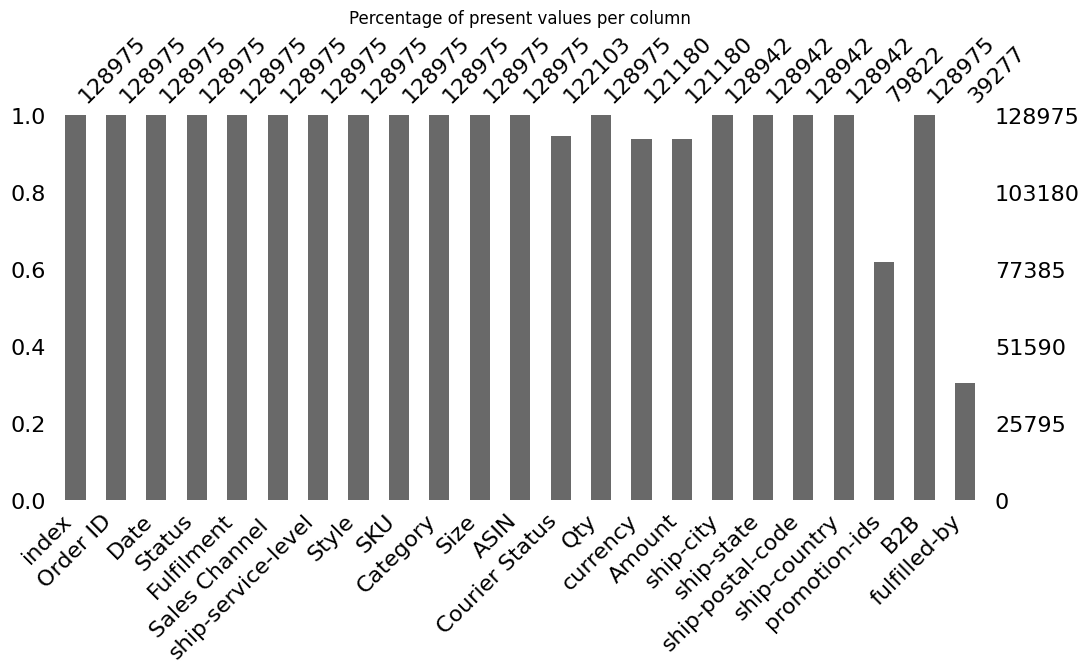

In [22]:
import missingno as msno
msno.bar(df, figsize=(12, 5))
plt.title("Percentage of present values per column")
plt.show()

### Checking Duplicates

In [23]:
df.duplicated().sum()

np.int64(0)

### Checking columns with the most missing values

In [24]:
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing

fulfilled-by          89698
promotion-ids         49153
currency               7795
Amount                 7795
Courier Status         6872
ship-city                33
ship-state               33
ship-country             33
ship-postal-code         33
Fulfilment                0
Sales Channel             0
Date                      0
Order ID                  0
index                     0
Status                    0
ship-service-level        0
ASIN                      0
Qty                       0
Size                      0
SKU                       0
Style                     0
Category                  0
B2B                       0
dtype: int64

## Convert Date column

In [25]:
df['Date'] = pd.to_datetime(
    df['Date'],
    format='%m-%d-%y'
)

In [26]:
df['Date'].dtype

dtype('<M8[ns]')

Validating if convertion was successful:

In [27]:
df['Date'].head()

0   2022-04-30
1   2022-04-30
2   2022-04-30
3   2022-04-30
4   2022-04-30
Name: Date, dtype: datetime64[ns]

## Analyze Amount nulls

In [28]:
df[df['Amount'].isnull()]['Status'].value_counts()

Status
Cancelled                       7566
Shipped                          208
Shipped - Delivered to Buyer       8
Shipping                           8
Shipped - Returned to Seller       3
Pending                            2
Name: count, dtype: int64

In [29]:
df = df[df['Amount'].notna()]

> Orders without revenue information were removed because they corresponded primarily to cancelled transactions.

## Analyze Courier Status

In [30]:
df[df['Courier Status'].isnull()]['Status'].value_counts()

Status
Cancelled    5136
Name: count, dtype: int64

In [31]:
df['Courier Status'] = df['Courier Status'].fillna('Cancelled')

## Analyze fulfilled-by

In [32]:
df['fulfilled-by'].value_counts(dropna=False)

fulfilled-by
NaN          83639
Easy Ship    37541
Name: count, dtype: int64

In [33]:
df['fulfilled-by'] = df['fulfilled-by'].fillna('Unknown')

## Analyze promotion-ids
Percentage of orders that had promorions:

In [34]:
df['promotion-ids'].notna().mean()*100

np.float64(65.59003135830996)

In [35]:
df['Promotion_Used'] = np.where(
    df['promotion-ids'].isna(),
    'No',
    'Yes'
)

In [36]:
df.drop(columns=['promotion-ids'], inplace=True)

## Analyze Shipping nulls
Percentage of orders that had null shipping directions:

In [37]:
33 / len(df) * 100

0.02723221653738241

In [38]:
df = df.dropna(
    subset=[
        'ship-city',
        'ship-state',
        'ship-country'
    ]
)

## Creating new variables

**Month**

In [39]:
df['Month'] = df['Date'].dt.month_name()

**Year**

In [40]:
df['Year'] = df['Date'].dt.year

**Weekday**

In [41]:
df['Weekday'] = df['Date'].dt.day_name()

**Weekend**

In [42]:
df['Weekend'] = np.where(
    df['Date'].dt.dayofweek >= 5,
    'Yes',
    'No'
)

Veryfing dates:

In [43]:
df[['Date','Year','Month','Weekday','Weekend']].head()

,Date,Year,Month,Weekday,Weekend
0,2022-04-30,2022,April,Saturday,Yes
1,2022-04-30,2022,April,Saturday,Yes
2,2022-04-30,2022,April,Saturday,Yes
3,2022-04-30,2022,April,Saturday,Yes
4,2022-04-30,2022,April,Saturday,Yes


## KPIs

In [44]:
total_revenue = df['Amount'].sum()
total_orders = df['Order ID'].nunique()
aov = df['Amount'].mean()
cancellation_rate = (df['Status'] == 'Cancelled').mean() * 100

print(f"Total Revenue: ${total_revenue:,.0f}")
print(f"Unique Orders: {total_orders:,}")
print(f"Average Ticket: ${aov:,.2f}")
print(f"Cancellation Rate: {cancellation_rate:.1f}%")

Total Revenue: $78,574,007
Unique Orders: 113,004
Average Ticket: $648.57
Cancellation Rate: 8.9%


## Veryfing duplicates

In [45]:
df.duplicated().sum()

np.int64(0)

## Checking Order Status

In [46]:
df['Status'].value_counts()

Status
Shipped                          77580
Shipped - Delivered to Buyer     28754
Cancelled                        10761
Shipped - Returned to Seller      1947
Shipped - Picked Up                973
Pending                            656
Pending - Waiting for Pick Up      281
Shipped - Returning to Seller      145
Shipped - Out for Delivery          35
Shipped - Rejected by Buyer         11
Shipped - Lost in Transit            5
Shipped - Damaged                    1
Name: count, dtype: int64

Simplifing variables:

In [47]:
df['Order_Status'] = np.where(
    df['Status'].str.contains('Cancelled', na=False),
    'Cancelled',
    'Completed'
)

## Cleaning Category

In [48]:
df['Category'].value_counts()

Category
Set              47031
kurta            46700
Western Dress    14703
Top              10163
Ethnic Dress      1093
Blouse             881
Bottom             420
Saree              155
Dupatta              3
Name: count, dtype: int64

In [49]:
df['Category'] = df['Category'].str.strip()

## Outliers

**Sales Distribution**

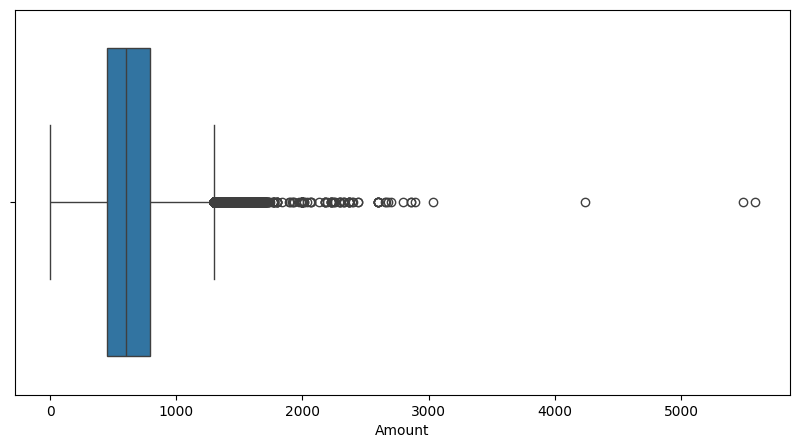

In [50]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=df['Amount']
)

plt.show()

**Percentile**

In [51]:
df['Amount'].quantile([0.25,0.5,0.75,0.95,0.99])

0.25     449.0
0.50     605.0
0.75     788.0
0.95    1176.0
0.99    1442.0
Name: Amount, dtype: float64

**In retail, outliers are usually valid transactions, so they will not be removed.**

# Final Clean Dataset

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 121149 entries, 0 to 128974
Data columns (total 28 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   index               121149 non-null  int64         
 1   Order ID            121149 non-null  object        
 2   Date                121149 non-null  datetime64[ns]
 3   Status              121149 non-null  object        
 4   Fulfilment          121149 non-null  object        
 5   Sales Channel       121149 non-null  object        
 6   ship-service-level  121149 non-null  object        
 7   Style               121149 non-null  object        
 8   SKU                 121149 non-null  object        
 9   Category            121149 non-null  object        
 10  Size                121149 non-null  object        
 11  ASIN                121149 non-null  object        
 12  Courier Status      121149 non-null  object        
 13  Qty                 121149 non-nul

### Export:

In [53]:
df.to_csv(
    'amazon_sales_clean.csv',
    index=False
)

# *Data Cleaning Summary*

1. Removed unnamed artifact column (col 23) — confirmed to carry no business meaning before dropping.
2. Converted Date to datetime using format %m-%d-%y — validated post-conversion.
3. Removed transactions without revenue — 99%+ were cancelled orders; imputation not appropriate.
4. Filled Courier Status nulls as 'Cancelled' — consistent with order status cross-reference.
5. Created binary Promotion_Used indicator from promotion-ids — original column dropped.
6. Standardized fulfilled-by nulls as 'Unknown' — preserved rows for analysis.
7. Dropped records with missing shipping geography (X rows, X%).
8. Engineered temporal features: Month, Year, Weekday, Weekend.
9. Final dataset: 121149 rows × 27 columns. No unexpected nulls remaining.